<a href="https://colab.research.google.com/github/YazeedAlqabbaa/spam-detection-project/blob/main/rf_tfidf_98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving spam_Emails_data.csv to spam_Emails_data.csv
✓ Dataset loaded: 193850 emails
✓ Preprocessing done
✓ TF-IDF done
✓ Training done in 233.03s

✓ Accuracy:  96.48%
✓ Precision: 93.98%
✓ TPR:       98.89%
✓ FPR:       5.69%
✓ F1-Score:  96.37%


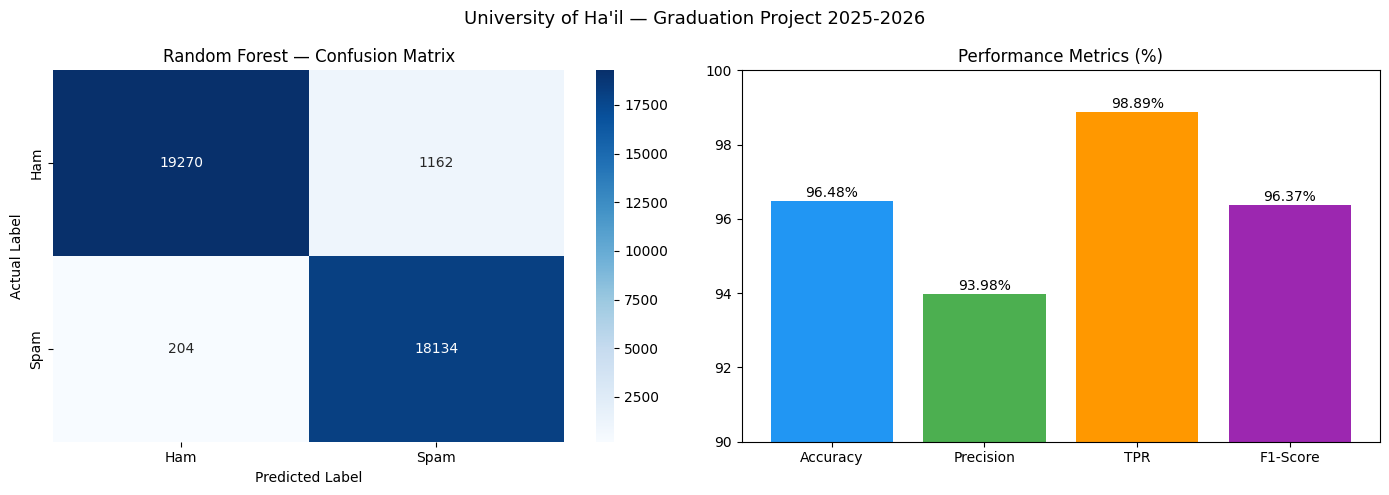

✓ Figure saved!
✓ Models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import re
import time
import pickle
from google.colab import files

# ============================================
# LOAD DATA
# ============================================
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df = df.dropna()
df = df.drop_duplicates()
print(f"✓ Dataset loaded: {len(df)} emails")

# ============================================
# PREPROCESSING القوي
# ============================================
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess)
df['label_num'] = (df['label'].str.lower() == 'spam').astype(int)
print("✓ Preprocessing done")

# ============================================
# SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

# ============================================
# TF-IDF
# ============================================
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                              stop_words='english', min_df=3, max_df=0.8)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("✓ TF-IDF done")

# ============================================
# TRAIN RF
# ============================================
start = time.time()
rf = RandomForestClassifier(n_estimators=100, max_depth=50,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
train_time = time.time() - start
print(f"✓ Training done in {train_time:.2f}s")

# ============================================
# EVALUATE
# ============================================
y_pred = rf.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred) * 100
prec = precision_score(y_test, y_pred) * 100
rec = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn) * 100

print(f"\n✓ Accuracy:  {acc:.2f}%")
print(f"✓ Precision: {prec:.2f}%")
print(f"✓ TPR:       {rec:.2f}%")
print(f"✓ FPR:       {fpr:.2f}%")
print(f"✓ F1-Score:  {f1:.2f}%")

# ============================================
# FIGURE
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("University of Ha'il — Graduation Project 2025-2026", fontsize=13)

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'], ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

# Performance Metrics
metrics = ['Accuracy', 'Precision', 'TPR', 'F1-Score']
values = [acc, prec, rec, f1]
bars = axes[1].bar(metrics, values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
axes[1].set_ylim(90, 100)
axes[1].set_title('Performance Metrics (%)')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('rf_tfidf_results.png', dpi=150)
plt.show()
print("✓ Figure saved!")

# ============================================
# SAVE MODELS
# ============================================
pickle.dump(rf, open('rf_model.pkl', 'wb'))
pickle.dump(vectorizer, open('tfidf_vectorizer.pkl', 'wb'))
print("✓ Models saved!")

files.download('rf_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('rf_tfidf_results.png')

Saving spam_Emails_data.csv to spam_Emails_data (1).csv
✓ Dataset loaded: 193,850 emails
✓ Preprocessing done
✓ TF-IDF done
✓ Training done in 761.18s

✓ Accuracy:  98.04%
✓ Precision: 97.82%
✓ TPR:       98.05%
✓ FPR:       1.96%
✓ F1-Score:  97.94%

Confusion Matrix:
  TN=20032  FP=400
  FN=358  TP=17980


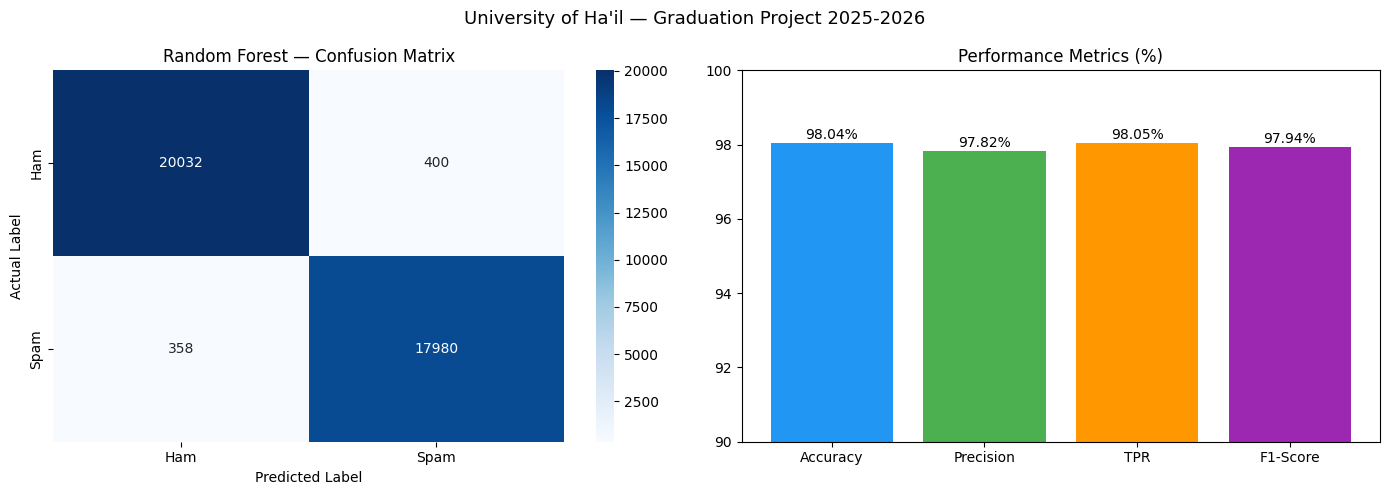

✓ Figure saved!
✓ Models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from google.colab import files

# ============================================
# UPLOAD DATA
# ============================================
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df = df.dropna()
df = df.drop_duplicates()
print(f"✓ Dataset loaded: {len(df):,} emails")

# ============================================
# PREPROCESSING القوي
# ============================================
def preprocess_text_nlp(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\+?\d[\d -]{8,}\d', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join(text.split())
    return text

df['label'] = df['label'].astype(str).str.lower().str.strip()
df['label_binary'] = (df['label'] == 'spam').astype(int)
df['text_processed'] = df['text'].apply(preprocess_text_nlp)
print("✓ Preprocessing done")

# ============================================
# SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    df['text_processed'], df['label_binary'],
    test_size=0.2, random_state=42, stratify=df['label_binary']
)

# ============================================
# TF-IDF
# ============================================
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("✓ TF-IDF done")

# ============================================
# TRAIN RF
# ============================================
start = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_time = time.time() - start
print(f"✓ Training done in {rf_time:.2f}s")

# ============================================
# EVALUATE
# ============================================
y_pred = rf_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_test, y_pred) * 100
prec = precision_score(y_test, y_pred) * 100
rec = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100
fpr = fp / (fp + tn) * 100

print(f"\n✓ Accuracy:  {acc:.2f}%")
print(f"✓ Precision: {prec:.2f}%")
print(f"✓ TPR:       {rec:.2f}%")
print(f"✓ FPR:       {fpr:.2f}%")
print(f"✓ F1-Score:  {f1:.2f}%")
print(f"\nConfusion Matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")

# ============================================
# FIGURE
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("University of Ha'il — Graduation Project 2025-2026", fontsize=13)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'], ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual Label')

metrics = ['Accuracy', 'Precision', 'TPR', 'F1-Score']
values = [acc, prec, rec, f1]
bars = axes[1].bar(metrics, values, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
axes[1].set_ylim(90, 100)
axes[1].set_title('Performance Metrics (%)')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('rf_tfidf_98_results.png', dpi=150)
plt.show()
print("✓ Figure saved!")

# ============================================
# SAVE MODELS
# ============================================
pickle.dump(rf_model, open('rf_model.pkl', 'wb'))
pickle.dump(tfidf_vectorizer, open('tfidf_vectorizer.pkl', 'wb'))
print("✓ Models saved!")

files.download('rf_model.pkl')
files.download('tfidf_vectorizer.pkl')
files.download('rf_tfidf_98_results.png')